In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.convolution import convolve, Box1DKernel, Gaussian1DKernel
from scipy.signal import argrelmin, argrelmax
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink
from utility.plot_spectrum import plot_spectrum
from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CONTINUUM_WINDOWS

relevant_erq_data_path = "data/relevant_erq_data.json"

data = pd.read_json(relevant_erq_data_path)

In [33]:
def get_ci(lam,profile,interval=0.997):
    cutoff = (1-interval)/2
    
    cumsum = np.cumsum(profile)
    cumsum /= np.max(cumsum)
    
    lower_idx = np.searchsorted(cumsum,cutoff)
    upper_idx = np.searchsorted(cumsum,1-cutoff,side="left")

    return (lam[lower_idx], lam[upper_idx])

In [34]:
def get_absorption_interval(lam, flux, ivar):
    mask = (lam > 1450) & (lam < 1650)

    lam, flux, ivar = lam[mask], flux[mask], ivar[mask]
    flux_conv = convolve(flux, Gaussian1DKernel(3))

    noise = np.where(ivar > 0, 1.0 / np.sqrt(np.maximum(ivar, 1e-30)), np.inf)

    mins = argrelmin(flux_conv)
    maxs = argrelmax(flux_conv)
    extrema_idxs = sorted(list(mins[0])+list((maxs[0])))
    mins_list = [(lam[i],flux_conv[i],noise[i],0) for i in mins[0]]
    maxs_list = [(lam[i],flux_conv[i],noise[i],1) for i in maxs[0]]
    extrema = pd.DataFrame(sorted(mins_list + maxs_list),columns=["lam","flux_conv","noise","max_bool"])
    extrema["flux_diff_backward"] = extrema["flux_conv"].diff().abs()
    extrema["flux_diff_forward"] = extrema["flux_conv"].diff(-1).abs()
    extrema["more_than_noise"] = (extrema["flux_diff_backward"] > 1.5*extrema["noise"]) & (extrema["flux_diff_forward"] > 1.5*extrema["noise"])
    extrema["overall_max_bool"] = extrema["flux_conv"] == extrema["flux_conv"].max()

    query = extrema.query("more_than_noise == 1 and max_bool == 0")

    if len(query) > 0:
        idx = query.index
        try:
            if extrema["overall_max_bool"][idx-1].squeeze() == True or extrema["overall_max_bool"][idx+1].squeeze() == True:

                lower = extrema["lam"][idx-1].squeeze()
                upper = extrema["lam"][idx+1].squeeze()
                five_percent = (upper - lower) * 0.05  # um nen puffer zu haben quasi

                absorption_interval = (lower+five_percent, upper-five_percent)

                return absorption_interval

        except ValueError:
            print("ValueError in get_absorption_interval()")

    return None

(1511.123683190865, 1573.2582294284755)


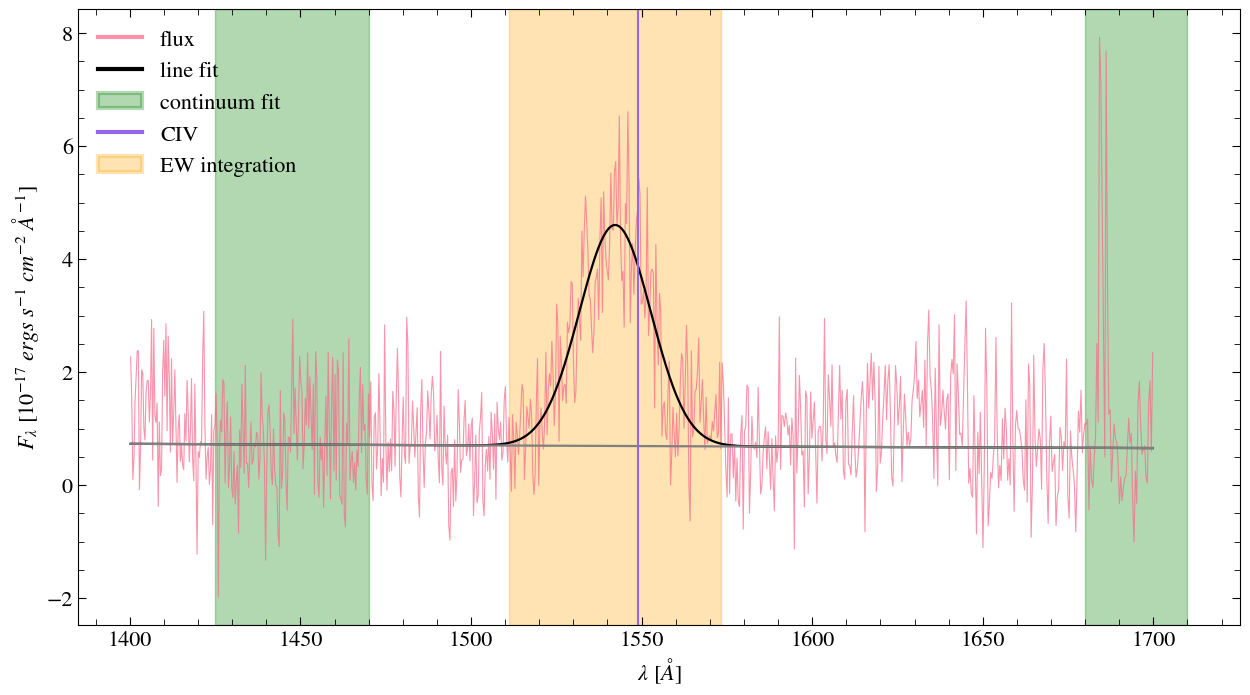


                SDSS: 000610.67+121501.2
                FWHM: 4776.732 vs 4540.061 (Hamann)
                REW: 152.598 vs 106.997 (Hamann) vs 147.823 (fit area)
                kt80: 0.372 vs 0.372 (Hamann)
    


In [35]:
for idx in range(1):

    lam = np.array(data["wavelength"][idx])
    flux = np.array(data["flux"][idx])
    ivar = np.array(data["ivar"][idx])
    z = data["redshift"][idx]

    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    # flux = convolve(flux, Gaussian1DKernel(1))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)

    if rejected:
        print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)

    # flux_clean = convolve(flux_clean, Box1DKernel(5))

    flux_sub = flux_clean - continuum if not rejected else None

    absorption_interval = get_absorption_interval(lam,flux,ivar)

    if absorption_interval is not None:
        bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
    else:
        bal_mask = None
    # bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    if accept_two:
        # sigma_w = result2.params["sigma_w"].value
        # sigma_c = result2.params["sigma_c"].value
        # mu_w = result2.params["cen_w"].value
        # mu_c = result2.params["cen_c"].value

        # lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
        # upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
        # ci = (lower,upper)

        profile = profile2
    else:
        # mu = result1.params["center"].value
        # sigma = result1.params["sigma"].value
        # ci = (mu-3*sigma, mu+3*sigma)
        
        profile = profile1

    # ci = (mu-2*sigma, mu+2*sigma)
    ci = get_ci(lam,profile)

    print(ci)

    plot_mask = (lam >= 1400) & (lam <= 1700)
    continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

    # flux_sub = convolve(flux_sub, Box1DKernel(7))

    if absorption_interval is not None:
        line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
    else:
        line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )

    out_str = f'''
                SDSS: {data["sdss_name"][idx]}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][idx],3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][idx],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
                kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][idx],3)} (Hamann)
    '''

    print(out_str)
    

### SNR at 1700

In [36]:
def get_nearest_index(array,value=1700):
    diffs = np.abs(array-value)
    idx = np.argmin(diffs)
    return idx


In [ ]:
def snr_at_1700A(lam,flux,ivar):
    diffs = np.abs(lam-1700)
    idx = np.argmin(diffs)

    snr = flux[idx] * np.sqrt(ivar[idx])  # snr=signal/noise, ivar=1/var², so snr=signal*sqrt(ivar)

    return snr

snr_at_1700A(lam,flux,ivar)

2.338258851991703

### visualize absorption to check logic 

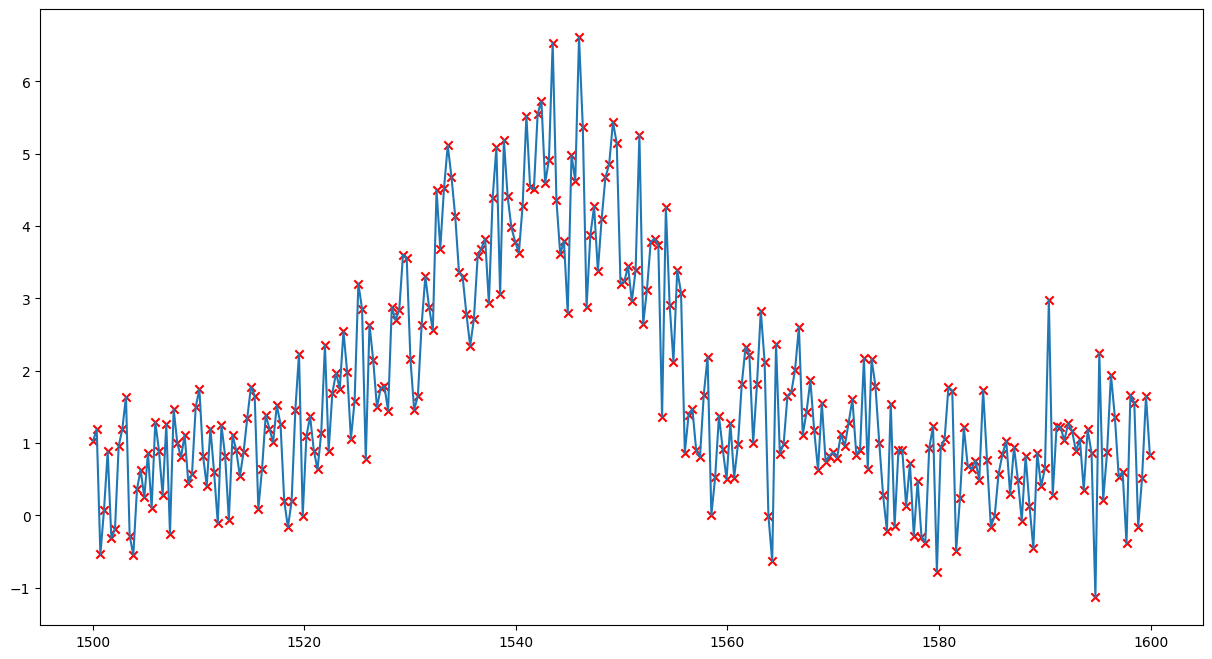

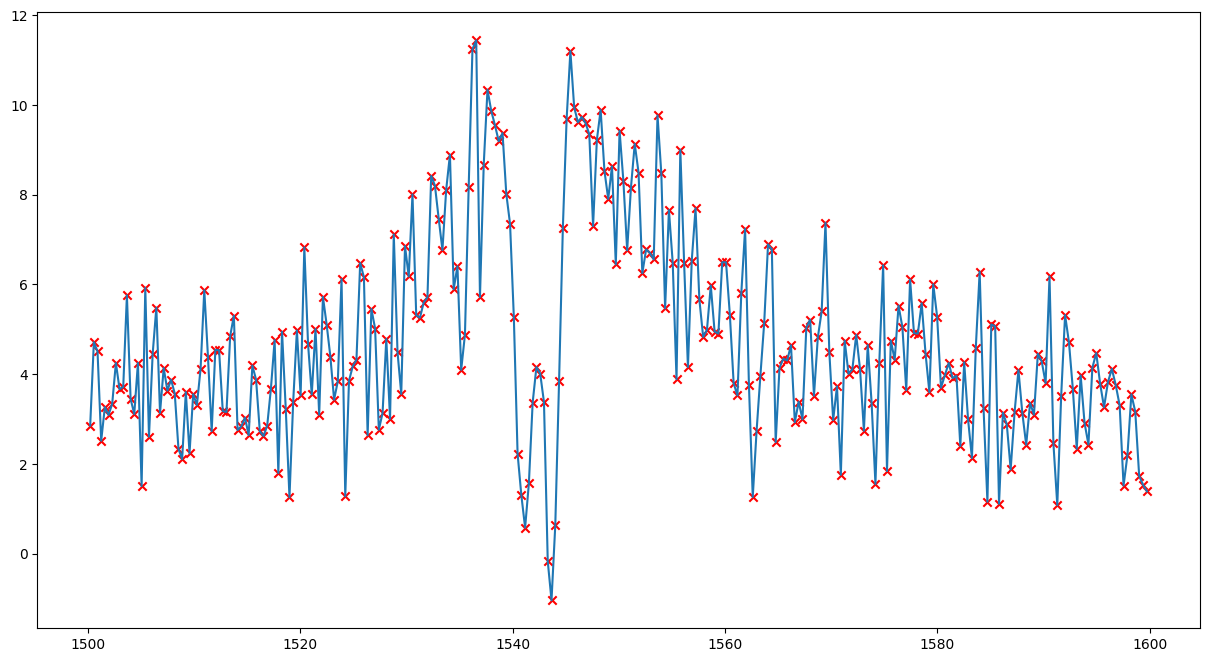

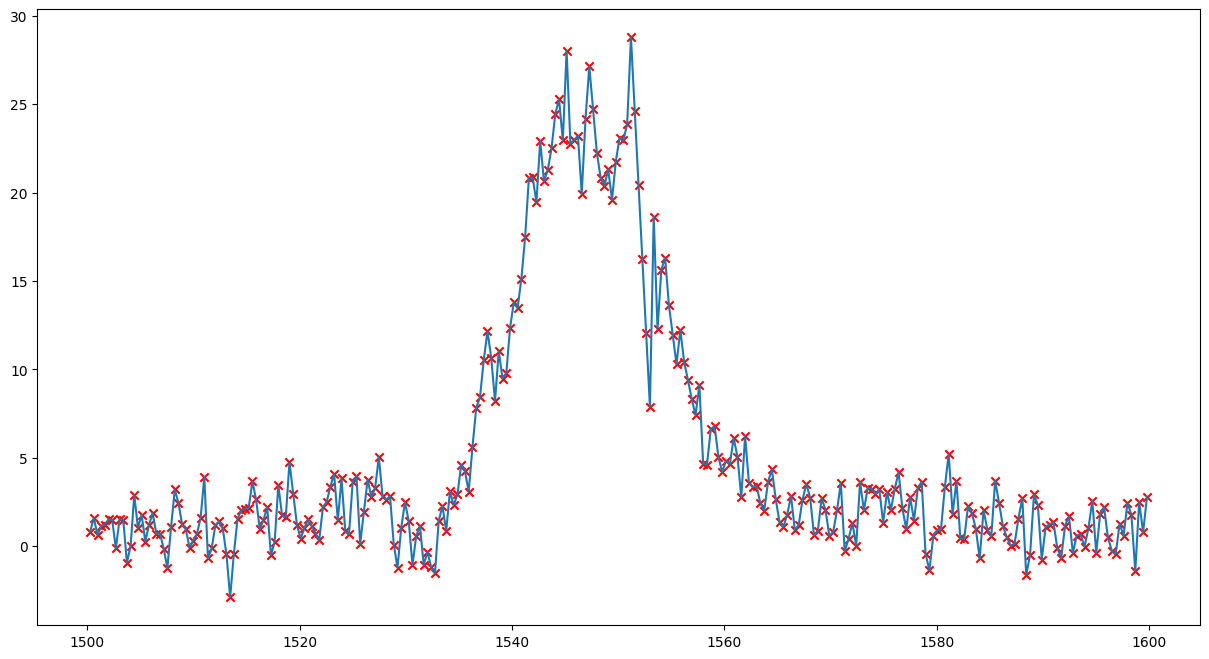

In [40]:
for idx in [0,4,16]:

    lam = np.array(data["wavelength"][idx])
    flux = np.array(data["flux"][idx])
    ivar = np.array(data["ivar"][idx])
    z = data["redshift"][idx]

    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    
    plt.subplots(figsize=(15,8))
    mask = (lam > 1500) & (lam < 1600)
    plt.plot(lam[mask],flux[mask])
    plt.scatter(lam[mask],flux[mask],color="red",marker="x")
    # plt.plot(lam,flux)

    # plt.scatter(lam[bal_mask & mask],flux[bal_mask & mask],color="red")

### test different convolution kernels

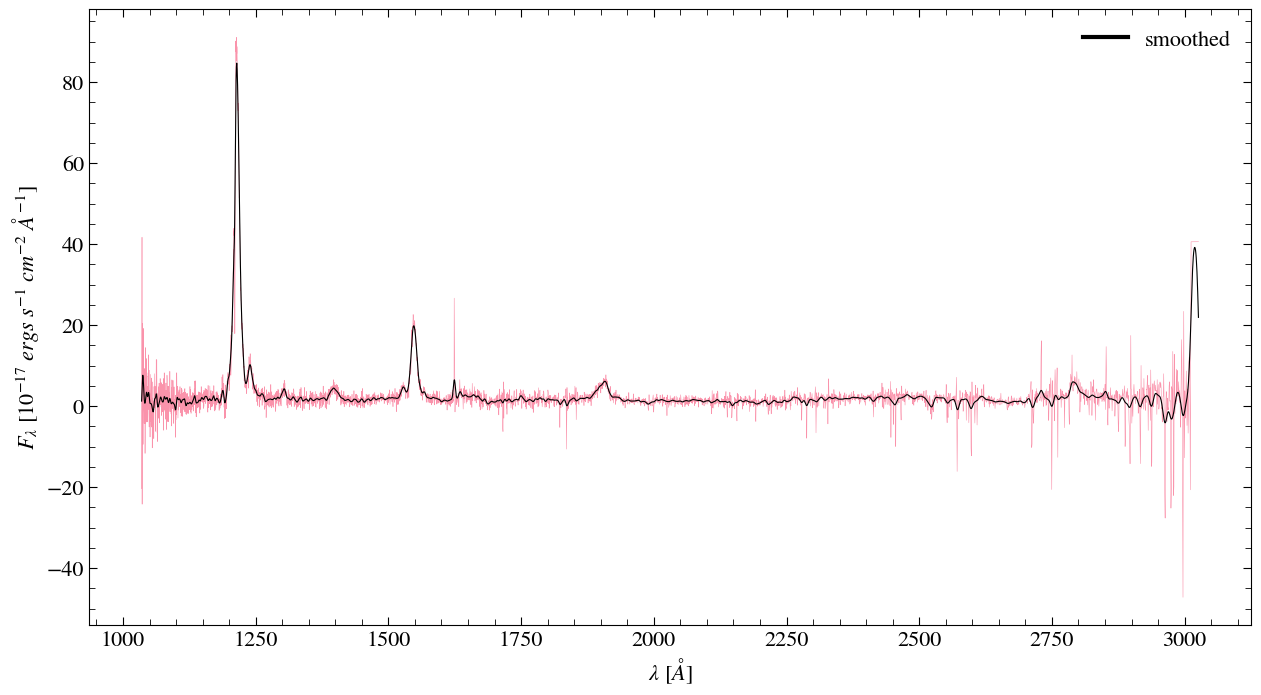

In [41]:
idx = 1
lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

plot_spectrum(lam,flux)

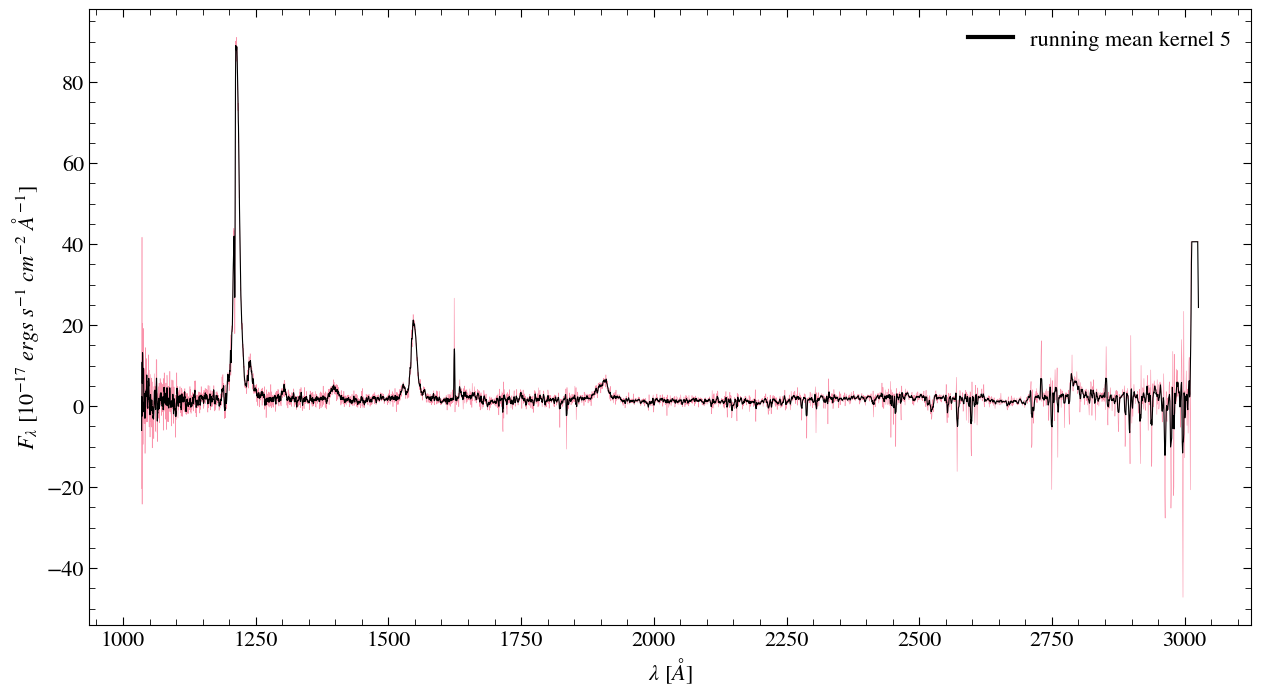

In [42]:
plot_spectrum(lam,flux,add_smoothed=False, additional_flux=[convolve(flux,Box1DKernel(5))],additional_flux_label=["running mean kernel 5"])